Accuracy: 77.7427869300082
              precision    recall  f1-score   support

           0       0.75      0.32      0.45     31200
           1       0.78      0.96      0.86     78670

    accuracy                           0.78    109870
   macro avg       0.77      0.64      0.66    109870
weighted avg       0.77      0.78      0.74    109870



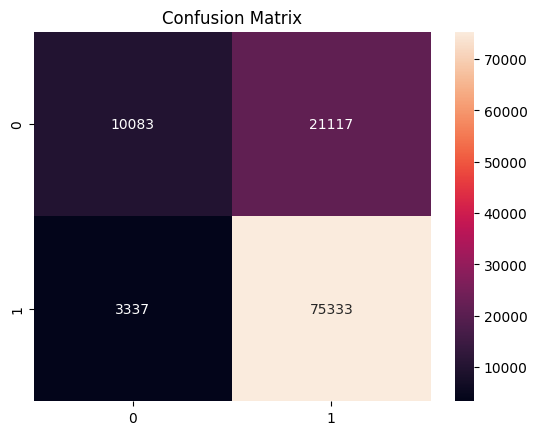

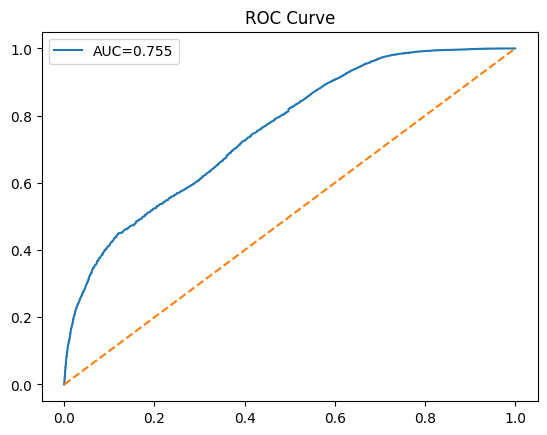

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

df = pd.read_csv('/content/phishing.csv')

# Feature Engineering: Extract numerical features from URL
def extract_url_features(df):
    df['url_length'] = df['URL'].apply(len)
    df['num_dots'] = df['URL'].apply(lambda x: x.count('.'))
    df['num_hyphens'] = df['URL'].apply(lambda x: x.count('-'))
    df['num_ques'] = df['URL'].apply(lambda x: x.count('?'))
    df['has_https'] = df['URL'].apply(lambda x: 1 if 'https' in x else 0)
    df['has_www'] = df['URL'].apply(lambda x: 1 if 'www' in x else 0)
    df['num_digits'] = df['URL'].apply(lambda x: sum(c.isdigit() for c in x))
    df['num_at'] = df['URL'].apply(lambda x: x.count('@'))
    df['num_slash'] = df['URL'].apply(lambda x: x.count('/'))
    df['num_percent'] = df['URL'].apply(lambda x: x.count('%'))
    df['num_equals'] = df['URL'].apply(lambda x: x.count('='))
    df['num_ampersand'] = df['URL'].apply(lambda x: x.count('&'))
    df['num_exclamation'] = df['URL'].apply(lambda x: x.count('!'))
    df['num_plus'] = df['URL'].apply(lambda x: x.count('+'))
    df['num_comma'] = df['URL'].apply(lambda x: x.count(','))
    df['num_underscore'] = df['URL'].apply(lambda x: x.count('_'))
    df['num_tilde'] = df['URL'].apply(lambda x: x.count('~'))
    df['num_colon'] = df['URL'].apply(lambda x: x.count(':'))
    return df.drop('URL', axis=1)

df_features = extract_url_features(df.copy())

X = df_features.drop('Label', axis=1)
y = df_features['Label']
# Convert 'bad' and 'good' string labels to numerical values
y = y.map({'bad': 0, 'good': 1})

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)
plt.plot(fpr,tpr,label="AUC="+str(round(roc_auc,4)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

Best Params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 77.77282242650405
              precision    recall  f1-score   support

           0       0.75      0.32      0.45     31200
           1       0.78      0.96      0.86     78670

    accuracy                           0.78    109870
   macro avg       0.77      0.64      0.66    109870
weighted avg       0.77      0.78      0.74    109870



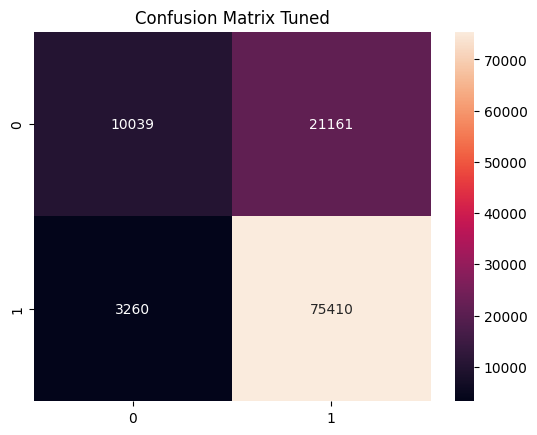

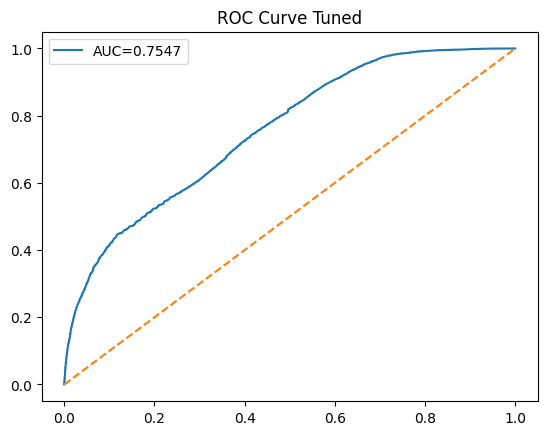

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

df = pd.read_csv('/content/phishing.csv')

# Feature Engineering: Extract numerical features from URL
def extract_url_features(df):
    df['url_length'] = df['URL'].apply(len)
    df['num_dots'] = df['URL'].apply(lambda x: x.count('.'))
    df['num_hyphens'] = df['URL'].apply(lambda x: x.count('-'))
    df['num_ques'] = df['URL'].apply(lambda x: x.count('?'))
    df['has_https'] = df['URL'].apply(lambda x: 1 if 'https' in x else 0)
    df['has_www'] = df['URL'].apply(lambda x: 1 if 'www' in x else 0)
    df['num_digits'] = df['URL'].apply(lambda x: sum(c.isdigit() for c in x))
    df['num_at'] = df['URL'].apply(lambda x: x.count('@'))
    df['num_slash'] = df['URL'].apply(lambda x: x.count('/'))
    df['num_percent'] = df['URL'].apply(lambda x: x.count('%'))
    df['num_equals'] = df['URL'].apply(lambda x: x.count('='))
    df['num_ampersand'] = df['URL'].apply(lambda x: x.count('&'))
    df['num_exclamation'] = df['URL'].apply(lambda x: x.count('!'))
    df['num_plus'] = df['URL'].apply(lambda x: x.count('+'))
    df['num_comma'] = df['URL'].apply(lambda x: x.count(','))
    df['num_underscore'] = df['URL'].apply(lambda x: x.count('_'))
    df['num_tilde'] = df['URL'].apply(lambda x: x.count('~'))
    df['num_colon'] = df['URL'].apply(lambda x: x.count(':'))
    return df.drop('URL', axis=1)

df_features = extract_url_features(df.copy())

X = df_features.drop('Label', axis=1)
y = df_features['Label']
y = y.map({'bad': 0, 'good': 1}) # Convert string labels to numerical

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

params = {'C':[0.01,0.1,1,10],'penalty':['l1','l2'],'solver':['liblinear']}

grid = GridSearchCV(LogisticRegression(max_iter=1000),params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Best Params:",grid.best_params_)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix Tuned")
plt.show()

fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)
plt.plot(fpr,tpr,label="AUC="+str(round(roc_auc,4)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Tuned")
plt.show()

MAE: 0.3558739488894125
MSE: 0.17229157475337825
RMSE: 0.4150802027962527
R2: 0.15265836714646075
Accuracy: 76.79257304086647


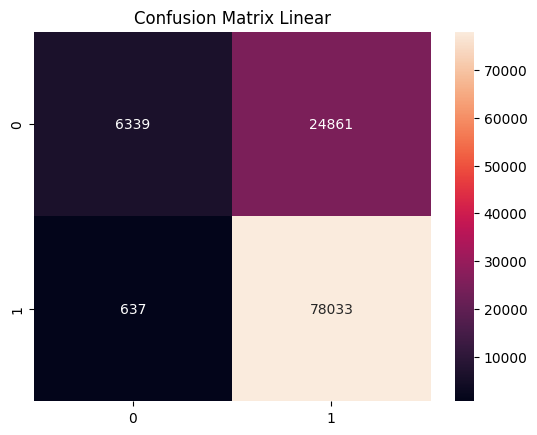

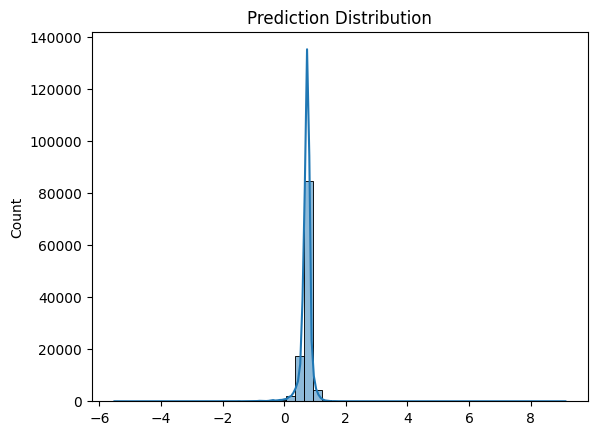

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

df = pd.read_csv('/content/phishing.csv')

X = df.drop('Result', axis=1)
y = df['Result']
y = y.replace(-1,0)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred_cont = model.predict(X_test)
y_pred = [1 if i>0.5 else 0 for i in y_pred_cont]

print("MAE:",mean_absolute_error(y_test,y_pred_cont))
print("MSE:",mean_squared_error(y_test,y_pred_cont))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_cont)))
print("R2:",r2_score(y_test,y_pred_cont))
print("Accuracy:",accuracy_score(y_test,y_pred)*100)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix Linear")
plt.show()

sns.histplot(y_pred_cont,bins=50,kde=True)
plt.title("Prediction Distribution")
plt.show()

Best Params: {'alpha': 10}
MAE: 0.3558787124728506
MSE: 0.17229133583807002
RMSE: 0.415079915002003
R2: 0.15265954214812694
Accuracy: 76.79257304086647


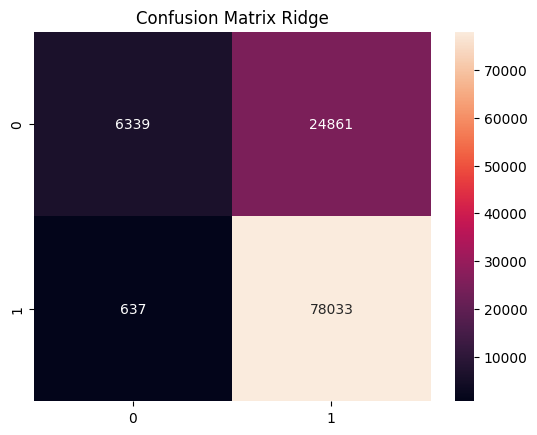

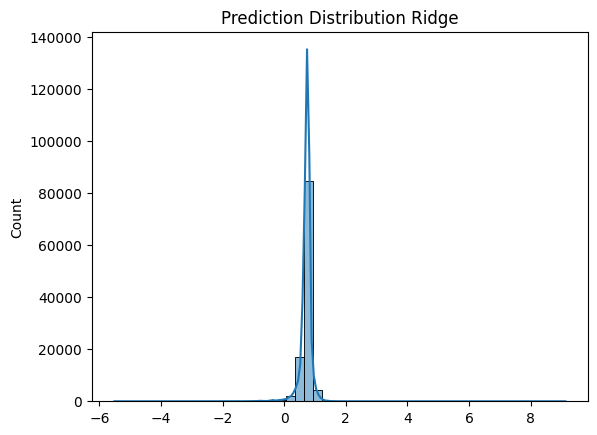

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

df = pd.read_csv('/content/phishing.csv')

# Feature Engineering: Extract numerical features from URL
def extract_url_features(df):
    df['url_length'] = df['URL'].apply(len)
    df['num_dots'] = df['URL'].apply(lambda x: x.count('.'))
    df['num_hyphens'] = df['URL'].apply(lambda x: x.count('-'))
    df['num_ques'] = df['URL'].apply(lambda x: x.count('?'))
    df['has_https'] = df['URL'].apply(lambda x: 1 if 'https' in x else 0)
    df['has_www'] = df['URL'].apply(lambda x: 1 if 'www' in x else 0)
    df['num_digits'] = df['URL'].apply(lambda x: sum(c.isdigit() for c in x))
    df['num_at'] = df['URL'].apply(lambda x: x.count('@'))
    df['num_slash'] = df['URL'].apply(lambda x: x.count('/'))
    df['num_percent'] = df['URL'].apply(lambda x: x.count('%'))
    df['num_equals'] = df['URL'].apply(lambda x: x.count('='))
    df['num_ampersand'] = df['URL'].apply(lambda x: x.count('&'))
    df['num_exclamation'] = df['URL'].apply(lambda x: x.count('!'))
    df['num_plus'] = df['URL'].apply(lambda x: x.count('+'))
    df['num_comma'] = df['URL'].apply(lambda x: x.count(','))
    df['num_underscore'] = df['URL'].apply(lambda x: x.count('_'))
    df['num_tilde'] = df['URL'].apply(lambda x: x.count('~'))
    df['num_colon'] = df['URL'].apply(lambda x: x.count(':'))
    return df.drop('URL', axis=1)

df_features = extract_url_features(df.copy())

X = df_features.drop('Label', axis=1)
y = df_features['Label']
y = y.map({'bad': 0, 'good': 1})

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

params = {'alpha':[0.01,0.1,1,10]}

grid = GridSearchCV(Ridge(),params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred_cont = model.predict(X_test)
y_pred = [1 if i>0.5 else 0 for i in y_pred_cont]

print("Best Params:",grid.best_params_)
print("MAE:",mean_absolute_error(y_test,y_pred_cont))
print("MSE:",mean_squared_error(y_test,y_pred_cont))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_cont)))
print("R2:",r2_score(y_test,y_pred_cont))
print("Accuracy:",accuracy_score(y_test,y_pred)*100)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix Ridge")
plt.show()

sns.histplot(y_pred_cont,bins=50,kde=True)
plt.title("Prediction Distribution Ridge")
plt.show()